In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

dataset_path = "/content/drive/MyDrive/multimodal_emotion_ Recognisation/TESS Toronto emotional speech set data"

print(os.listdir(dataset_path)[:5])

['OAF_angry', 'OAF_disgust', 'OAF_Fear', 'OAF_happy', 'OAF_neutral']


In [3]:
!pip install tensorflow scikit-learn seaborn

In [4]:
import os

dataset_path = "/content/drive/MyDrive/multimodal_emotion_ Recognisation/TESS Toronto emotional speech set data"

for root, dirs, files in os.walk(dataset_path):

    for file in files[:20]:

        print(file)

OAF_fail_angry.wav
OAF_chalk_angry.wav
OAF_burn_angry.wav
OAF_ditch_angry.wav
OAF_base_angry.wav
OAF_beg_angry.wav
OAF_dog_angry.wav
OAF_back_angry.wav
OAF_bought_angry.wav
OAF_cheek_angry.wav
OAF_choice_angry.wav
OAF_gap_angry.wav
OAF_check_angry.wav
OAF_bath_angry.wav
OAF_death_angry.wav
OAF_fat_angry.wav
OAF_boat_angry.wav
OAF_bite_angry.wav
OAF_bean_angry.wav
OAF_cause_angry.wav
OAF_chair_disgust.wav
OAF_back_disgust.wav
OAF_boat_disgust.wav
OAF_book_disgust.wav
OAF_burn_disgust.wav
OAF_base_disgust.wav
OAF_bar_disgust.wav
OAF_chain_disgust.wav
OAF_bite_disgust.wav
OAF_choice_disgust.wav
OAF_cab_disgust.wav
OAF_bean_disgust.wav
OAF_bath_disgust.wav
OAF_chat_disgust.wav
OAF_came_disgust.wav
OAF_check_disgust.wav
OAF_calm_disgust.wav
OAF_cause_disgust.wav
OAF_cheek_disgust.wav
OAF_beg_disgust.wav
OAF_check_fear.wav
OAF_dead_fear.wav
OAF_chief_fear.wav
OAF_cab_fear.wav
OAF_deep_fear.wav
OAF_bone_fear.wav
OAF_bite_fear.wav
OAF_book_fear.wav
OAF_dime_fear.wav
OAF_date_fear.wav
OAF_cool_

In [5]:
# IMPORT LIBRARIES


import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Flatten

In [6]:

# EXTRACT TEXT AND EMOTION LABELS

texts = []
labels = []

print("Loading text data...")

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):


            filename = file.replace(".wav", "")



            parts = filename.split("_")

            word = parts[1].lower().strip()

            emotion = parts[-1].lower().strip()

            emotion = emotion.split(" ")[0]


            # STORE DATA


            texts.append(word)
            labels.append(emotion)

print("Dataset Loaded Successfully!")

print("\nSample Texts:")
print(texts[:10])

print("\nEmotion Classes:")
print(sorted(set(labels)))

print("\nTotal Text Samples:")
print(len(texts))

Loading text data...
Dataset Loaded Successfully!

Sample Texts:
['fail', 'chalk', 'burn', 'ditch', 'base', 'beg', 'dog', 'back', 'bought', 'cheek']

Emotion Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']

Total Text Samples:
2802


In [7]:

# TOKENIZATION

tokenizer = Tokenizer()

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

X = pad_sequences(
    sequences,
    padding='post'
)

print("Tokenized Text Shape:", X.shape)

Tokenized Text Shape: (2802, 1)


In [8]:

# LABEL ENCODING


encoder = LabelEncoder()

y_encoded = encoder.fit_transform(labels)

y = to_categorical(y_encoded)

print("Emotion Classes:")
print(encoder.classes_)

Emotion Classes:
['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']


In [9]:

# BUILD TEXT MODEL


from tensorflow.keras.layers import Flatten

vocab_size = len(tokenizer.word_index) + 1

model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=32,
        input_length=X.shape[1]
    )
)
# FLATTEN LAYER

model.add(Flatten())

# DENSE LAYER

model.add(Dense(64, activation='relu'))

# DROPOUT

model.add(Dropout(0.3))

model.add(Dense(y.shape[1], activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.build(input_shape=(None, X.shape[1]))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 1, 32)          │         6,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,999 (35.15 KB)

 Trainable params: 8,999 (35.15 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 2241
Testing Samples: 561


In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.1254 - loss: 1.9491 - val_accuracy: 0.0891 - val_loss: 1.9523
Epoch 2/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1343 - loss: 1.9472 - val_accuracy: 0.0553 - val_loss: 1.9576
Epoch 3/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1272 - loss: 1.9461 - val_accuracy: 0.0267 - val_loss: 1.9617
Epoch 4/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1553 - loss: 1.9447 - val_accuracy: 0.0285 - val_loss: 1.9678
Epoch 5/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1446 - loss: 1.9441 - val_accuracy: 0.0089 - val_loss: 1.9748
Epoch 6/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1526 - loss: 1.9420 - val_accuracy: 0.0089 - val_loss: 1.9832
Epoch 7/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1593 - loss: 1.9419 - val_accuracy: 0.0036 - val_loss: 1.9919
Epoch 8/8
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1566 - loss: 1.9386 - val_accuracy: 0.0036 - val_loss: 2.0

In [12]:

# MODEL EVALUATION

loss, accuracy = model.evaluate(X_test, y_test)

print("\nText Model Accuracy:", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0036 - loss: 2.0049

Text Model Accuracy: 0.003565062303096056


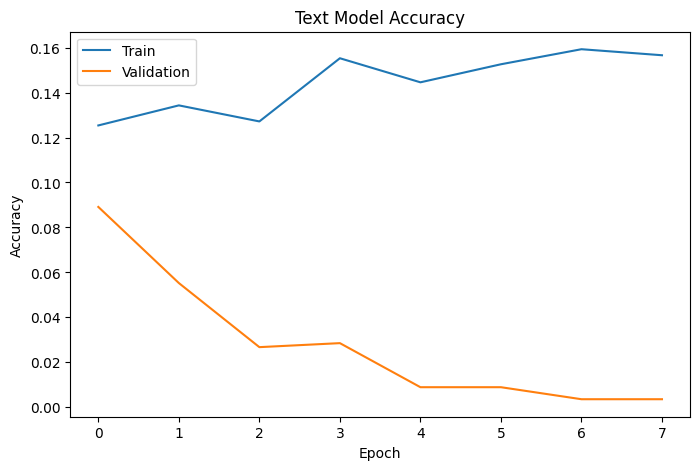

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


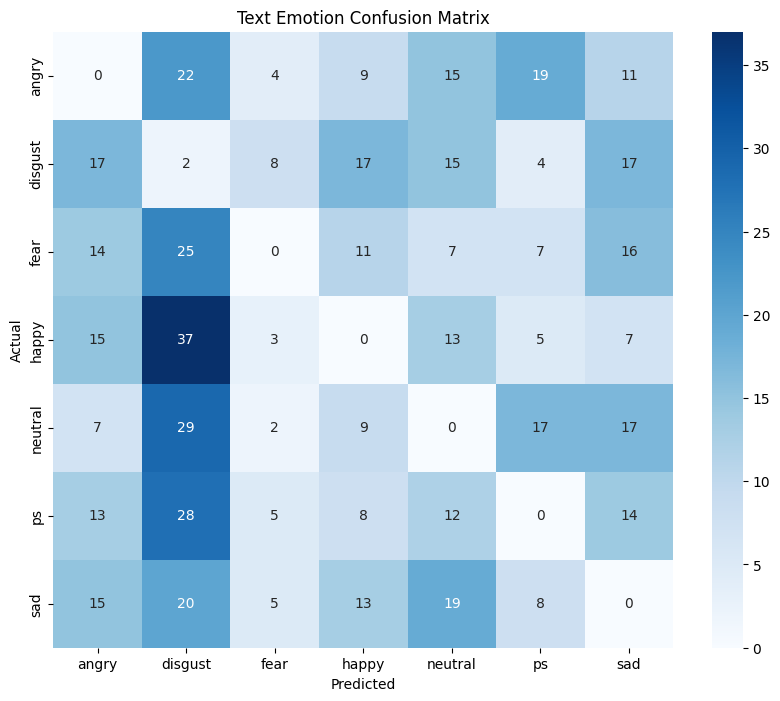

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        80
     disgust       0.01      0.03      0.02        80
        fear       0.00      0.00      0.00        80
       happy       0.00      0.00      0.00        80
     neutral       0.00      0.00      0.00        81
          ps       0.00      0.00      0.00        80
         sad       0.00      0.00      0.00        80

    accuracy                           0.00       561
   macro avg       0.00      0.00      0.00       561
weighted avg       0.00      0.00      0.00       561



In [13]:

# ACCURACY PLOT

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Text Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

# CONFUSION MATRIX


y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Text Emotion Confusion Matrix")

plt.show()

# CLASSIFICATION REPORT


y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=encoder.classes_,
        zero_division=0
    )
)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


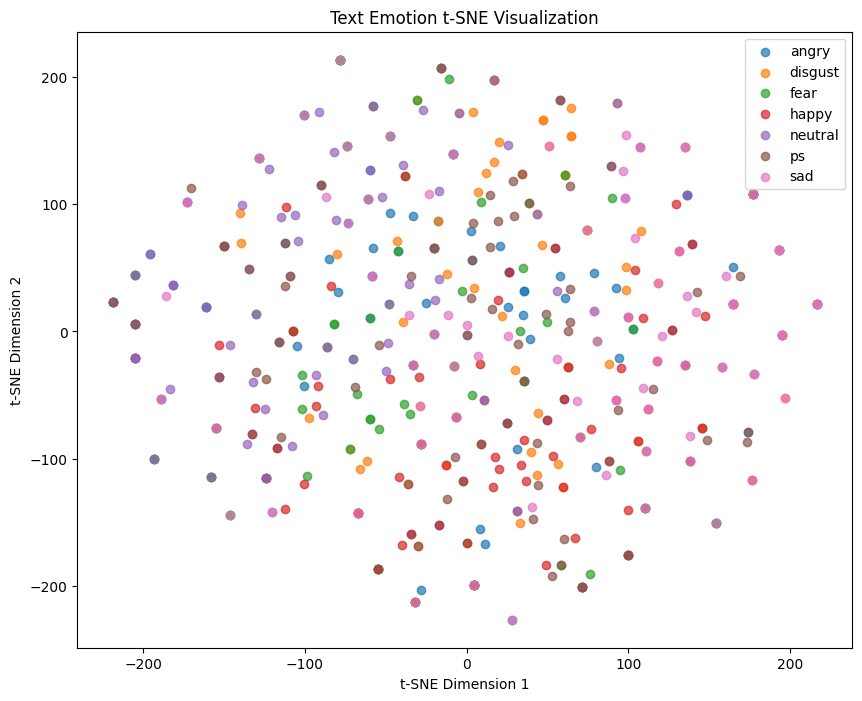

In [14]:

# t-SNE VISUALIZATION


from sklearn.manifold import TSNE
from tensorflow.keras.models import Model


feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)

text_embeddings = feature_extractor.predict(X_test)

# APPLY t-SNE


tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

text_tsne = tsne.fit_transform(text_embeddings)

# VISUALIZATION

plt.figure(figsize=(10,8))

for emotion_index, emotion_name in enumerate(encoder.classes_):

    indices = np.where(y_true == emotion_index)

    plt.scatter(
        text_tsne[indices, 0],
        text_tsne[indices, 1],
        label=emotion_name,
        alpha=0.7
    )

plt.title("Text Emotion t-SNE Visualization")

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend()

plt.show()

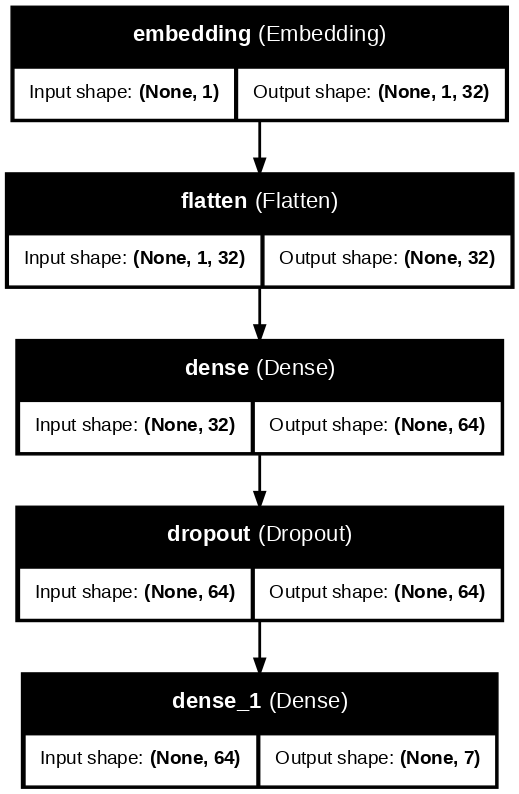

In [15]:

# ARCHITECTURE DIAGRAM

from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)

In [16]:

# SAVE MODEL

model.save("/content/drive/MyDrive/multimodal_emotion_ Recognisation/text_emotion_model.keras")

print("Text model saved successfully.")

Text model saved successfully.
